## Data collection and Preliminary Analysis

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from zipfile import ZipFile

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score






from random import randint





path = r"archive.zip"

def view_data(path):

    with ZipFile(path, "r") as f:
        f.printdir()

def load_data(path):
    with ZipFile(path, "r") as zip_data:
        with zip_data.open("winequality-white.csv") as f:
            data_file = pd.read_csv(f, sep=";")
            return data_file


In [2]:
view_data(path)


File Name                                             Modified             Size
winequality-white.csv                          2020-09-28 11:10:38       264426
winequality.names                              2020-09-28 11:10:38         3233


In [3]:
df = load_data(path)
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [4]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

## DATA CLEANING

## EDA

In [5]:
df.describe().T.style.background_gradient(axis=0)

,count,mean,std,min,25%,50%,75%,max
fixed acidity,4898.000000,6.854788,0.843868,3.800000,6.300000,6.800000,7.300000,14.200000
volatile acidity,4898.000000,0.278241,0.100795,0.080000,0.210000,0.260000,0.320000,1.100000
citric acid,4898.000000,0.334192,0.121020,0.000000,0.270000,0.320000,0.390000,1.660000
residual sugar,4898.000000,6.391415,5.072058,0.600000,1.700000,5.200000,9.900000,65.800000
chlorides,4898.000000,0.045772,0.021848,0.009000,0.036000,0.043000,0.050000,0.346000
free sulfur dioxide,4898.000000,35.308085,17.007137,2.000000,23.000000,34.000000,46.000000,289.000000
total sulfur dioxide,4898.000000,138.360657,42.498065,9.000000,108.000000,134.000000,167.000000,440.000000
density,4898.000000,0.994027,0.002991,0.987110,0.991723,0.993740,0.996100,1.038980
pH,4898.000000,3.188267,0.151001,2.720000,3.090000,3.180000,3.280000,3.820000
sulphates,4898.000000,0.489847,0.114126,0.220000,0.410000,0.470000,0.550000,1.080000


In [6]:
df.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [7]:
# reclassifying quality

df.replace({"quality": {9: "best", 8: "best", 7: "good", 6: "good", 5: "average", 4: "Poor", 3: "poor", 2: "poor"}}, inplace=True)

## Preprocessing

## DATA SPLITTING

In [8]:



X = df.drop(columns="quality")

Y = df["quality"]

# lets scale the features

scaler = MinMaxScaler(feature_range=(0, 1))
x_scaled = scaler.fit_transform(X)



x_train, x_test, y_train, y_test = train_test_split(
    x_scaled, Y, 
    test_size=0.2,
    random_state=234,
    shuffle= True,
    stratify=Y
)

## Modelling

Training Logistic Regression
Logistic Regression Accuracy: 0.7081632653061225


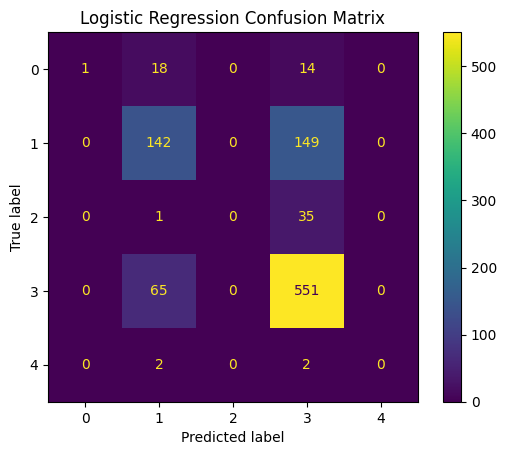

Training RandomForest
RandomForest Accuracy: 0.7989795918367347


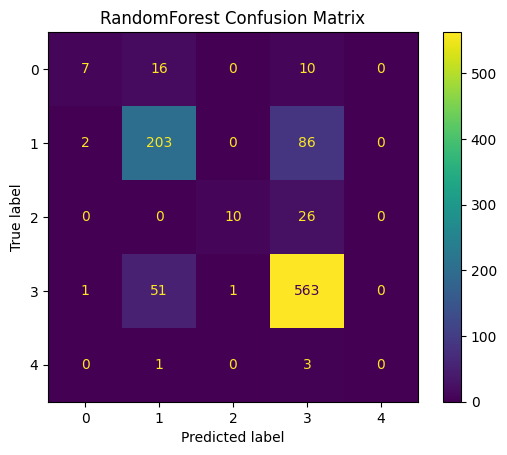

Training Decision Tree
Decision Tree Accuracy: 0.7275510204081632


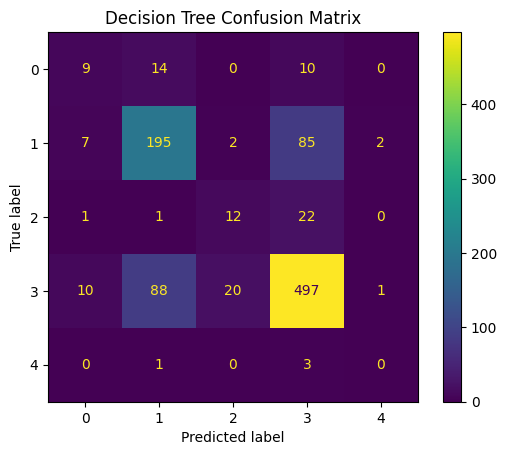

Training K Nearest Neighbors
K Nearest Neighbors Accuracy: 0.6887755102040817


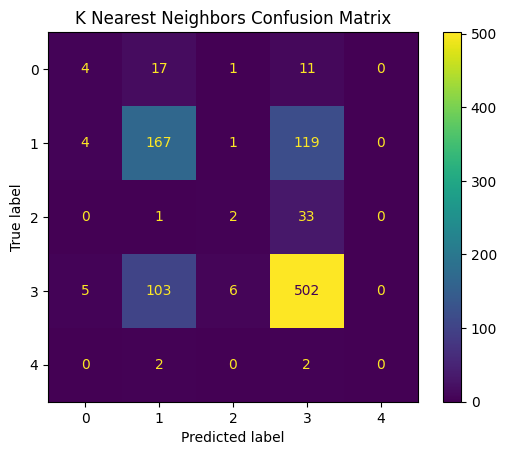

Training Naive Bayes
Naive Bayes Accuracy: 0.6326530612244898


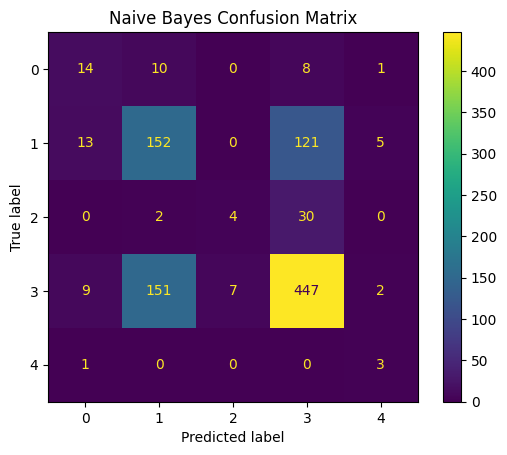


Model performance summary:
Logistic Regression: 0.7082
RandomForest: 0.7990
Decision Tree: 0.7276
K Nearest Neighbors: 0.6888
Naive Bayes: 0.6327


In [9]:

models = {
    "Logistic Regression": LogisticRegression(),
    "RandomForest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "K Nearest Neighbors": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}

results = {}
for model_name, model in models.items():

    print(f"Training {model_name}")
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[model_name] = accuracy
    print(f"{model_name} Accuracy: {accuracy}")

    # lets include confusion matrix 
    
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

print("\nModel performance summary:")
for model_name, acc in results.items():
    print(f"{model_name}: {acc:.4f}")


In [10]:
# lets get parameters for random forest (Best Classifier)

rf = RandomForestClassifier()
rf.get_params()




{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [11]:
param_dist = {
    'n_estimators': randint(50, 200),
    'max_depth': randint(10, 20),
    'min_samples_split': (2, 10),
    'min_samples_leaf': (1, 4),
}





In [12]:
# tuning randomforest - Hyperparameters

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

In [13]:
# define randomsearch

random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=234),
    param_distributions = param_grid
    

)

random_search.fit(x_train, y_train)

print(f"Best Parameters for RandomForest: {random_search.best_estimator_}")

Best Parameters for RandomForest: RandomForestClassifier(max_depth=30, n_estimators=50, random_state=234)


# Model Training (Fitting)

In [14]:
Best_Model = random_search.best_estimator_
cv_scores = cross_val_score(Best_Model, x_scaled, Y, cv=5)




print(f"cross-validation for RandomForest: {cv_scores}")
print(f"mean cross-validation score: {cv_scores.mean()}")

cross-validation for RandomForest: [0.65       0.65102041 0.71428571 0.69356486 0.70990807]
mean cross-validation score: 0.6837558108023598


## Evaluation

In [15]:



y_pred = Best_Model.predict(x_test)
print(classification_report(y_test, y_pred, zero_division=1))

              precision    recall  f1-score   support

        Poor       0.57      0.12      0.20        33
     average       0.73      0.69      0.71       291
        best       1.00      0.31      0.47        36
        good       0.81      0.91      0.86       616
        poor       1.00      0.00      0.00         4

    accuracy                           0.79       980
   macro avg       0.82      0.40      0.45       980
weighted avg       0.79      0.79      0.77       980



### saving model and scaler for backend calls (fastapi)

In [16]:
joblib.dump(Best_Model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("scaler and best model saved successfully")

scaler and best model saved successfully
